In [2]:
import sys
sys.path.append('../../src')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pprint import pprint
import pickle
import json
from datetime import datetime
import warnings
import random

import math
import geopandas as gpd

import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib_venn import venn2
import plotly.express as px
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error
)
from sklearn.exceptions import UndefinedMetricWarning

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, BatchNormalization
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.callbacks import EarlyStopping

import mlflow
from inequalipy import gini

from util_IO import (
    load_pickle_from_main_project_dir,
    load_timeseries_df,
    load_attributes_df,
    get_stadiamaps_provider_api_key_in_env,
    get_mlflow_tracking_uri,
    geo_plot_basic
)

# Set pandas to display a maximum of 300 columns
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 1000)

# Suppress the SettingWithCopyWarning
pd.options.mode.chained_assignment = None

pd.set_option('display.float_format', '{:.3f}'.format)

# Suppresses warnings related to the R² score by year
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Set seed
random.seed(82)
np.random.seed(82)
tf.random.set_seed(82)

# Retrieve provider for maps
stadiamaps_provider = get_stadiamaps_provider_api_key_in_env()

# Set mlflow server
mlflow.set_tracking_uri(
    uri=get_mlflow_tracking_uri()
)

# Set autolog properties
mlflow.keras.autolog()

2025-10-21 12:52:33.187787: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 12:52:35.928080: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/lib/x86_64-linux-gnu/:/opt/conda/lib
2025-10-21 12:52:35.928266: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local

In [4]:
aggr_parameters_dict, camels_gb_use_case_dir = load_pickle_from_main_project_dir(
    'aggr_parameters_dict.pkl'
)

In [5]:
def calculate_mape(actual, predicted):
    """
    Calculate Mean Absolute Percentage Error (MAPE)
    
    Parameters:
    actual (list or array): Actual values
    predicted (list or array): Predicted values
    
    Returns:
    float: MAPE value as a percentage
    """
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Define NSE function
def nse(obs, sim):
    obs = np.array(obs)
    sim = np.array(sim)
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    return 1 - numerator / denominator if denominator != 0 else np.nan

In [85]:
run = "6"

In [86]:
train_results_df = pd.read_csv(f"../../temp/validation_runs/{run}/train_error_analysis_df.csv")
test_results_df = pd.read_csv(f"../../temp/validation_runs/{run}/test_error_analysis_df.csv")
test_results_df["date"] = test_results_df["end_date"]

In [87]:
test_results_df[['catchmentID', 'y_test', 'y_test_hat', 'date']].head()

,catchmentID,y_test,y_test_hat,date
0,101005,0.085,0.128,1990-11-03
1,101005,0.081,0.110,1990-11-04
2,101005,0.079,0.107,1990-11-05
3,101005,0.076,0.104,1990-11-06
4,101005,0.074,0.097,1990-11-07


In [88]:
y_test = test_results_df["y_test"]
y_test_hat = test_results_df["y_test_hat"]
y_train = train_results_df["y_train"]
y_train_hat = train_results_df["y_train_hat"]

In [89]:
print(round(y_train.mean(),2))
print(round(y_test.mean(),2))

6.31
5.09


In [90]:
print(round(np.std(y_train),2))
print(round(np.std(y_test),2))

21.89
17.65


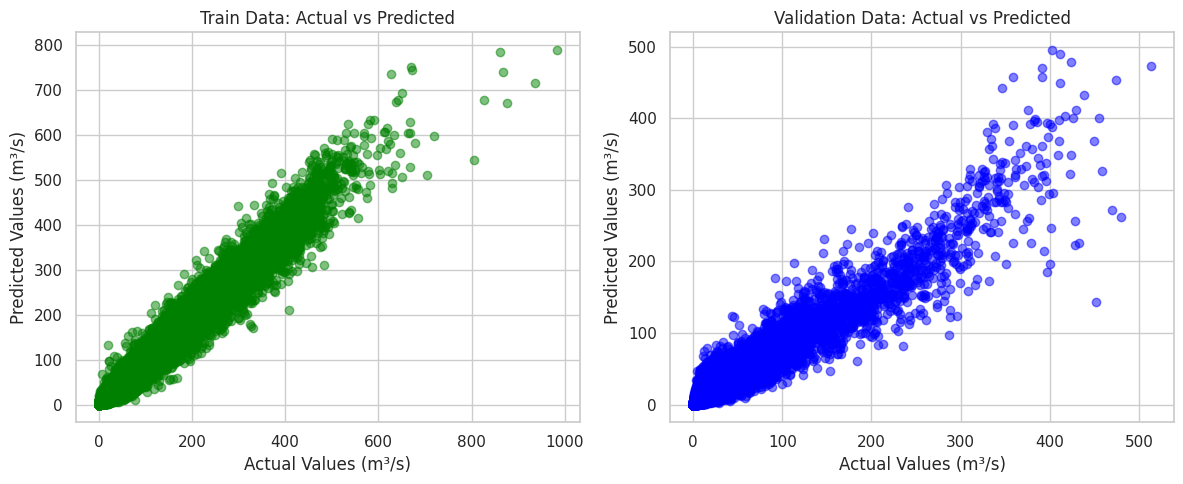

In [91]:
plt.figure(figsize=(12, 5))

# Train data scatter plot (now on the left)
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_hat, alpha=0.5, color='green')
plt.title('Train Data: Actual vs Predicted')
plt.xlabel('Actual Values (m³/s)')
plt.ylabel('Predicted Values (m³/s)')
plt.grid(True)

# Validation data scatter plot (now on the right)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_hat, alpha=0.5, color='blue')
plt.title('Validation Data: Actual vs Predicted')
plt.xlabel('Actual Values (m³/s)')
plt.ylabel('Predicted Values (m³/s)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [92]:
# Global metrics
global_mae = mean_absolute_error(test_results_df['y_test'], test_results_df['y_test_hat'])

# Calculate MAE and NSE per catchmentID
catchment_mae = test_results_df.groupby('catchmentID').apply(
    lambda g: mean_absolute_error(g['y_test'], g['y_test_hat'])
)

print("MAE (Global):", round(global_mae, 2))
print("MAE (by catchment):", round(catchment_mae.mean(), 2))

MAE (Global): 1.6
MAE (by catchment): 1.59


/var/tmp/ipykernel_7001/1316821743.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_mae = test_results_df.groupby('catchmentID').apply(


In [93]:

global_nse = nse(test_results_df['y_test'], test_results_df['y_test_hat'])
print("NSE (Global):", round(global_nse, 2))

# Calculate MAE and NSE per catchmentID
catchment_nse = test_results_df.groupby('catchmentID').apply(
    lambda g: nse(g['y_test'], g['y_test_hat'])
)
print("NSE (by catchment):", round(catchment_nse.mean(), 2))

NSE (Global): 0.91
NSE (by catchment): -0.75


/var/tmp/ipykernel_7001/1383412580.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_nse = test_results_df.groupby('catchmentID').apply(


In [94]:
# Calculate MEAN and MEAN per catchmentID
global_mean = test_results_df['y_test'].mean()
catchment_mean = test_results_df.groupby('catchmentID').apply(
    lambda g: g['y_test'].mean()
)
print("MEAN (Global):", round(global_mean, 2))
print("MEAN of means (by catchment):", round(catchment_mean.mean(), 2))

MEAN (Global): 5.09
MEAN of means (by catchment): 5.07


/var/tmp/ipykernel_7001/1305640769.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_mean = test_results_df.groupby('catchmentID').apply(


In [95]:
# Calculate SD and SD per catchmentID
global_sd = np.std(test_results_df['y_test'])
catchment_mean = test_results_df.groupby('catchmentID').apply(
    lambda g: np.std(g['y_test'])
)
print("SD (Global):", round(global_sd, 2))
print("MEAN of SDs (by catchment):", round(catchment_mean.mean(), 2))

SD (Global): 17.65
MEAN of SDs (by catchment): 6.06


/var/tmp/ipykernel_7001/3946112701.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_mean = test_results_df.groupby('catchmentID').apply(


In [96]:
# Group by catchmentID and calculate MAE, count, and NSE
train_grouped = train_results_df.groupby('catchmentID').agg(
    mae=('y_train_abs_diff', 'mean'),
    count=('y_train_abs_diff', 'size'),
    nse=('catchmentID', lambda x: nse(
        train_results_df.loc[x.index, 'y_train'],
        train_results_df.loc[x.index, 'y_train_hat']
    ))
).reset_index()

# Group by catchmentID and calculate MAE, count, and NSE
test_grouped = test_results_df.groupby('catchmentID').agg(
    mae=('y_test_abs_diff', 'mean'),
    count=('y_test_abs_diff', 'size'),
    nse=('catchmentID', lambda x: nse(
        test_results_df.loc[x.index, 'y_test'],
        test_results_df.loc[x.index, 'y_test_hat']
    ))
).reset_index()

In [97]:
# Sort by MAE ascending
grouped_sorted = test_grouped.sort_values(by='mae')

# Select catchments until cumulative count reaches 69%-79% of total
total_count = test_results_df.shape[0]
target_min = 0.69 * total_count
target_max = 0.79 * total_count

selected_catchments = []
cumulative_count = 0
cumulative_mae_values = []

for _, row in grouped_sorted.iterrows():
    if cumulative_count >= target_max:
        break
    selected_catchments.append(row['catchmentID'])
    cumulative_count += row['count']

df_selected = test_results_df[test_results_df["catchmentID"].isin(selected_catchments)]
df_remaining = test_results_df[~test_results_df["catchmentID"].isin(selected_catchments)]

combined_mae_selected = mean_absolute_error(df_selected["y_test"], df_selected["y_test_hat"])
combined_mae_remaining = mean_absolute_error(df_remaining["y_test"], df_remaining["y_test_hat"])

# Calculate MAE and NSE per catchmentID
catchment_mae = df_selected.groupby('catchmentID').apply(
    lambda g: mean_absolute_error(g['y_test'], g['y_test_hat'])
)

# Take the mean across catchments
mean_mae_selected = catchment_mae.mean()
max_mae_selected = catchment_mae.max()
min_mae_selected = catchment_mae.min()

catchment_mae_remaining = df_remaining.groupby('catchmentID').apply(
    lambda g: mean_absolute_error(g['y_test'], g['y_test_hat'])
)

mean_mae_remaining = catchment_mae_remaining.mean()
max_mae_remaining = catchment_mae_remaining.max()
min_mae_remaining = catchment_mae_remaining.min()

coverage_percentage = cumulative_count / total_count * 100

# Output
print("Percentage of Data Represented by selected catchments:", round(coverage_percentage, 2), "%")
print("Mean MAE for selected catchments:", round(mean_mae_selected, 2))
print("Max MAE for selected catchments:", round(max_mae_selected, 2))
print("Min MAE for selected catchments:", round(min_mae_selected, 2))
print("Combined MAE for selected catchments:", round(combined_mae_selected, 2))
print("Percentage of Data Represented NOT selected catchments:", round(100 - coverage_percentage, 2), "%")
print("Mean MAE for remaining catchments:", round(mean_mae_remaining, 2))
print("Max MAE for remaining catchments:", round(max_mae_remaining, 2))
print("Min MAE for remaining catchments:", round(min_mae_remaining, 2))
print("Combined MAE for remaining catchments:", round(combined_mae_remaining, 2))

Percentage of Data Represented by selected catchments: 79.99 %
Mean MAE for selected catchments: 0.72
Max MAE for selected catchments: 2.36
Min MAE for selected catchments: 0.06
Combined MAE for selected catchments: 0.73
Percentage of Data Represented NOT selected catchments: 20.01 %
Mean MAE for remaining catchments: 5.16
Max MAE for remaining catchments: 14.51
Min MAE for remaining catchments: 2.37
Combined MAE for remaining catchments: 5.08


/var/tmp/ipykernel_7001/982055279.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_mae = df_selected.groupby('catchmentID').apply(
/var/tmp/ipykernel_7001/982055279.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_mae_remaining = df_remaining.groupby('catchmentID').apply(


In [98]:
# Sort by MAE ascending
grouped_sorted = test_grouped.sort_values(by='nse', ascending=False)

# Select catchments until cumulative count reaches 69%-79% of total
total_count = test_results_df.shape[0]
target_min = 0.69 * total_count
target_max = 0.79 * total_count

selected_catchments = []
cumulative_count = 0

cumulative_nse_values = []

for _, row in grouped_sorted.iterrows():
    if cumulative_count >= target_max:
        break
    selected_catchments.append(row['catchmentID'])
    cumulative_count += row['count']

df_selected = test_results_df[test_results_df["catchmentID"].isin(selected_catchments)]
df_remaining = test_results_df[~test_results_df["catchmentID"].isin(selected_catchments)]

combined_nse_selected = nse(df_selected["y_test"], df_selected["y_test_hat"])
combined_nse_remaining = nse(df_remaining["y_test"], df_remaining["y_test_hat"])

# Calculate MAE and NSE per catchmentID
catchment_nse = df_selected.groupby('catchmentID').apply(
    lambda g: nse(g['y_test'], g['y_test_hat'])
)

# Take the mean across catchments
mean_nse_selected = catchment_nse.mean()
max_nse_selected = catchment_nse.max()
min_nse_selected = catchment_nse.min()

catchment_nse_remaining = df_remaining.groupby('catchmentID').apply(
    lambda g: nse(g['y_test'], g['y_test_hat'])
)

mean_nse_remaining = catchment_nse_remaining.mean()
max_nse_remaining = catchment_nse_remaining.max()
min_nse_remaining = catchment_nse_remaining.min()

coverage_percentage = cumulative_count / total_count * 100

# Output
print("Percentage of Data Represented by selected catchments:", round(coverage_percentage, 2), "%")
print("Mean NSE for selected catchments:", round(mean_nse_selected, 2))
print("Max NSE for selected catchments:", round(max_nse_selected, 2))
print("Min NSE for selected catchments:", round(min_nse_selected, 2))
print("Combined NSE for selected catchments:", round(combined_nse_selected, 2))
print("Percentage of Data Represented NOT selected catchments:", round(100 - coverage_percentage, 2), "%")
print("Mean NSE for remaining catchments:", round(mean_nse_remaining, 2))
print("Max NSE for remaining catchments:", round(max_nse_remaining, 2))
print("Min NSE for remaining catchments:", round(min_nse_remaining, 2))
print("Combined NSE for remaining catchments:", round(combined_nse_remaining, 2))

/var/tmp/ipykernel_7001/2489536932.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_nse = df_selected.groupby('catchmentID').apply(


Percentage of Data Represented by selected catchments: 80.04 %
Mean NSE for selected catchments: 0.54
Max NSE for selected catchments: 0.96
Min NSE for selected catchments: -0.5
Combined NSE for selected catchments: 0.92
Percentage of Data Represented NOT selected catchments: 19.96 %
Mean NSE for remaining catchments: -5.81
Max NSE for remaining catchments: -0.61
Min NSE for remaining catchments: -49.36
Combined NSE for remaining catchments: -1.65


/var/tmp/ipykernel_7001/2489536932.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_nse_remaining = df_remaining.groupby('catchmentID').apply(


# Catchment metrics

In [99]:
grouped_sorted["Run"] = str(run)

In [100]:
grouped_sorted.to_csv(f"../../temp/validation_catchment_metrics_run={run}.csv")

In [101]:
# Replace these with the paths to your actual CSV files
file1 = '../../temp/validation_catchment_metrics_run=1.csv'
file2 = '../../temp/validation_catchment_metrics_run=2.csv'
file3 = '../../temp/validation_catchment_metrics_run=3.csv'

# Read each CSV file
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

# Concatenate the DataFrames
combined_df = pd.concat([df1, df2, df3], ignore_index=True)

In [102]:
combined_df.to_csv(f"../../temp/validation_catchment_metrics_all_runs.csv")

# Map plots

In [103]:
# Variables picked
date_field = aggr_parameters_dict['timeseries']['date_field']
attributes_index = aggr_parameters_dict["attributes"]["attributes_index"]
camels_gb_datasets_dir = aggr_parameters_dict["camels_gb_datasets_dir"]
camels_gb_data_attributes_aggr_dir = aggr_parameters_dict["camels_gb_data_attributes_aggr_dir"]
camels_gb_data_timeseries_aggr_dir = aggr_parameters_dict['camels_gb_data_timeseries_aggr_dir']
camels_gb_bronze_dir = aggr_parameters_dict['camels_gb_bronze_dir']
camels_gb_silver_dir = aggr_parameters_dict['camels_gb_silver_dir']

temp_files_dir = f"{camels_gb_use_case_dir}/temp"

In [104]:
# Load polygons
gdf_catchments = gpd.read_file(
    os.path.join(
        camels_gb_bronze_dir,
        'CAMELS_GB_catchment_boundaries',
        'CAMELS_GB_catchment_boundaries.shp'
    )
)

# Derive area in squared km
gdf_catchments['area_sqkm'] = gdf_catchments['geometry'].area / 1e6

In [105]:
# Retrieving flow gauging station locations
gauging_station_locations = load_attributes_df(
    camels_gb_data_attributes_aggr_dir,
    "fundamental_locations_postFEa.csv",
    attributes_index
)

# Convert flow gauging station locations pandas df into geopandas
gdf_gauging_station_locations = (
    gpd.GeoDataFrame(
        gauging_station_locations,
        geometry=(
            gpd.points_from_xy(
                gauging_station_locations['gauge_lon'],
                gauging_station_locations['gauge_lat']
            )
        ),
        crs="EPSG:4326"
    )
)
gdf_gauging_station_locations = gdf_gauging_station_locations.to_crs(gdf_catchments.crs)


# Merge
# ⚠️ `right` join -> `gdf_catchments` reduces in rows
gdf_catchments = (
    gdf_catchments
        .merge(
            gdf_gauging_station_locations,
            left_on='ID_STRING',
            right_index=True,
            how='right',
            suffixes=(
                '_catchment',
                '_flow-gauging-station'
            )
        )
)

assert gdf_catchments.isna().sum().sum() == 0, "Some unexpected NaN"


# Rename the geometry columns
gdf_catchments = (
    gdf_catchments
        .rename(
            columns={
                'geometry_catchment': 'catchment_geom',
                'geometry_flow-gauging-station': 'flow-gauging-station_geom'
            }
        )
)


# Set one as the active geometry
gdf_catchments = gdf_catchments.set_geometry('flow-gauging-station_geom')

In [106]:
# Read the file into a DataFrame
chalk_streams_df = pd.read_csv(
    os.path.join(
        camels_gb_datasets_dir,
        "chalk_streams.csv"
    ),
    dtype={attributes_index: 'str'},
    index_col=attributes_index
)

gdf_catchments = (
    gdf_catchments
        .merge(
            chalk_streams_df,
            left_on='ID_STRING',
            right_index=True,
            how='left'
        )
)

assert gdf_catchments.isna().sum().sum() == 0, "Some unexpected NaN"

In [107]:
def get_catchments_grouped_by(
    group_by_lists,
    df,
    set_name
):

    # Define output
    results = []

    # Set aggregation function to use
    combined_agg_funcs = get_combined_agg_funcs(
        set_name,
        df
    )

    # Loop on group-by(s)
    for group_by_list in group_by_lists:

        # Initialize specific data frame
        curr_grouped_by_df = (
            df.groupby(
                group_by_list
            )
            .agg(**combined_agg_funcs)
            .sort_values(
                f"y_{set_name}_abs_%_diff_avg",
                ascending=True
            )
        )

        # Store the data frame
        results.append(curr_grouped_by_df)

    return tuple(results)

In [108]:
gdf_catchments['ID_STRING'] = gdf_catchments['ID_STRING'].astype(str)
train_grouped['catchmentID'] = train_grouped['catchmentID'].astype(str)
test_grouped['catchmentID'] = test_grouped['catchmentID'].astype(str)

train_gdf_catchments_merged = (
    gdf_catchments
        .merge(
            train_grouped,
            left_on='ID_STRING',
            right_on='catchmentID',
            how='inner'
        )
)
test_gdf_catchments_merged = (
    gdf_catchments
        .merge(
            test_grouped,
            left_on='ID_STRING',
            right_on='catchmentID',
            how='inner'
        )
)

In [109]:
train_gdf_catchments_merged["y_train_nse"] = train_gdf_catchments_merged["nse"]
test_gdf_catchments_merged["y_test_nse"] = test_gdf_catchments_merged["nse"]

In [110]:
def get_norm(metric, vmin, vmax):

    if metric in ['diff_avg', '%_diff_avg', 'nse']:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    return norm


def format_colorbar_ticks(
    colorbar,
    lb_powerlimits=-3,
    ub_powerlimits=3
):
    colorbar.formatter.set_powerlimits((lb_powerlimits, ub_powerlimits))
    colorbar.formatter.set_useMathText(True)


def get_error_map(
    train_gdf,
    test_gdf,
    metric_name,
    cmap,
    stadiamaps_provider,
    filter_train=None,
    filter_test=None
):
    
    # Define column names based on the pattern
    y_train_col = f'y_train_{metric_name}'
    y_test_col = f'y_test_{metric_name}'

    # Get colour map object
    cmap = plt.get_cmap(cmap)
    
    # Apply the colormap to the error metric columns for train and test data
    train_color = train_gdf[y_train_col].apply(lambda x: mcolors.to_hex(cmap(x)))
    test_color = test_gdf[y_test_col].apply(lambda x: mcolors.to_hex(cmap(x)))

    # Create a figure with 2 rows and 1 column
    fig, axes = plt.subplots(1, 2, figsize=(10, 20))

    # Apply filters if provided
    if filter_train is not None:
        train_gdf_queried = train_gdf.query(filter_train)
        train_color = train_color.loc[train_gdf_queried.index]
    else:
        train_gdf_queried = train_gdf
    if filter_test is not None:
        test_gdf_queried = test_gdf.query(filter_test)
        test_color = test_color.loc[test_gdf_queried.index]
    else:
        test_gdf_queried = test_gdf

    # Plot for train data
    geo_plot_basic(train_gdf_queried, stadiamaps_provider, ax=axes[0], color=train_color)
    axes[0].set_title('Train')
    axes[0].set_xlabel(metric_name)

    # Plot for test data
    geo_plot_basic(test_gdf_queried, stadiamaps_provider, ax=axes[1], color=test_color)
    axes[1].set_title('Validation')
    axes[1].set_xlabel(metric_name)

    # Create ScalarMappable for train data
    norm_train = get_norm(metric_name, train_gdf[y_train_col].min(), train_gdf[y_train_col].max())
    sm_train = plt.cm.ScalarMappable(cmap=cmap, norm=norm_train)
    sm_train.set_array([])
    # sm_train.set_clim(train_gdf_queried[y_train_col].min(), train_gdf_queried[y_train_col].max())

    # Create ScalarMappable for test data
    norm_test = get_norm(metric_name, test_gdf[y_test_col].min(), test_gdf[y_test_col].max())
    sm_test = plt.cm.ScalarMappable(cmap=cmap, norm=norm_test)
    sm_test.set_array([])
    # sm_test.set_clim(test_gdf_queried[y_test_col].min(), test_gdf_queried[y_test_col].max())
    

    # Add the colorbar to the plot as a legend for train data
    cbar_train = fig.colorbar(sm_train, ax=axes[0], orientation='horizontal', fraction=0.01, pad=0.015)
    # cbar_train.ax.set_ylim(
    #     train_gdf_queried[y_train_col].min(),
    #     train_gdf_queried[y_train_col].max()
    # )

    # Add the colorbar to the plot as a legend for test data
    cbar_test = fig.colorbar(sm_test, ax=axes[1], orientation='horizontal', fraction=0.01, pad=0.015)
    # cbar_test.ax.set_ylim(
    #     test_gdf_queried[y_test_col].min(),
    #     test_gdf_queried[y_test_col].max()
    # )

    sm_train.set_clim(-1, 1)
    sm_test.set_clim(-1, 1)

    # Adjust ticks
    format_colorbar_ticks(cbar_train)
    format_colorbar_ticks(cbar_test)

    # Adjust layout and show the plot
    plt.tight_layout()

    # Combine both GeoDataFrames
    combined_gdf = pd.concat([train_gdf, test_gdf])
    
    # Get total bounds: [minx, miny, maxx, maxy]
    min_lon, min_lat, max_lon, max_lat = combined_gdf.total_bounds

    for ax in axes:
        ax.set_xlim(min_lon, max_lon)
        ax.set_ylim(min_lat, max_lat)
    
    return fig

In [111]:
# Set variables and cmap
vars_plotted_on_map = [('nse', 'RdYlGn')]

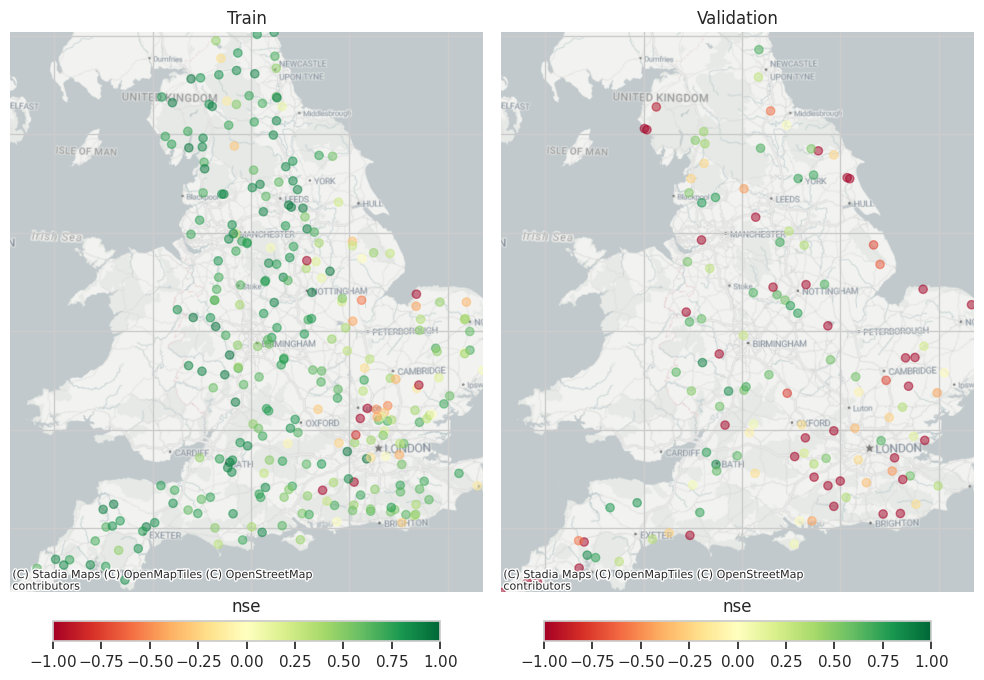

In [112]:
# ALL CATCHMENTS IN SAMPLE

for geometry in ['flow-gauging-station_geom']:

    # Set geometry
    (
        train_gdf_catchments_merged
            .set_geometry(
                geometry,
                inplace=True
            )
    )
    
    (
        test_gdf_catchments_merged
            .set_geometry(
                geometry,
                inplace=True
            )
    )

    for var, cmap in vars_plotted_on_map:
        
        # Get plot
        fig = get_error_map(
            train_gdf_catchments_merged,
            test_gdf_catchments_merged,
            var,
            cmap,
            stadiamaps_provider,
        )

        # fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
    
        # Log
        mlflow.log_figure(
            fig,
            f"error_analysis/catchment/charts/errors_map_{var}_{geometry}_all_sample.png",
            save_kwargs={'bbox_inches': 'tight'}
        )
    
        # Show
        plt.show()

# Time series plots

In [113]:
# Best and worst catchments
sorted_data = test_grouped[["catchmentID", "nse"]].sort_values(by='nse')
low = int(sorted_data.head(1)["catchmentID"].item())
high = int(sorted_data.tail(1)["catchmentID"].item())

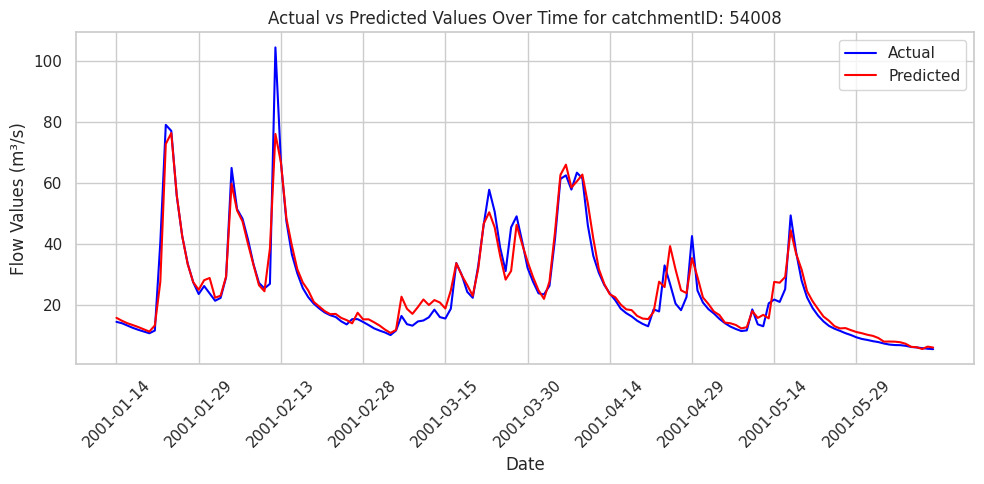

In [114]:
catchment_df = test_results_df[test_results_df["catchmentID"]==high]

n = 5*30

# Prepare data
dates = catchment_df["end_date"].tolist()[:n]
actual = catchment_df["y_test"].tolist()[:n]
predicted = catchment_df["y_test_hat"].tolist()[:n]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, actual, color='blue', label='Actual')
plt.plot(dates, predicted, color='red', label='Predicted')

# Show only 10 evenly spaced ticks on the x-axis
plt.xticks(ticks=pd.Series(dates).iloc[::len(dates)//10], rotation=45)

plt.title(f"Actual vs Predicted Values Over Time for catchmentID: {high}")
plt.xlabel("Date")
plt.ylabel("Flow Values (m³/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

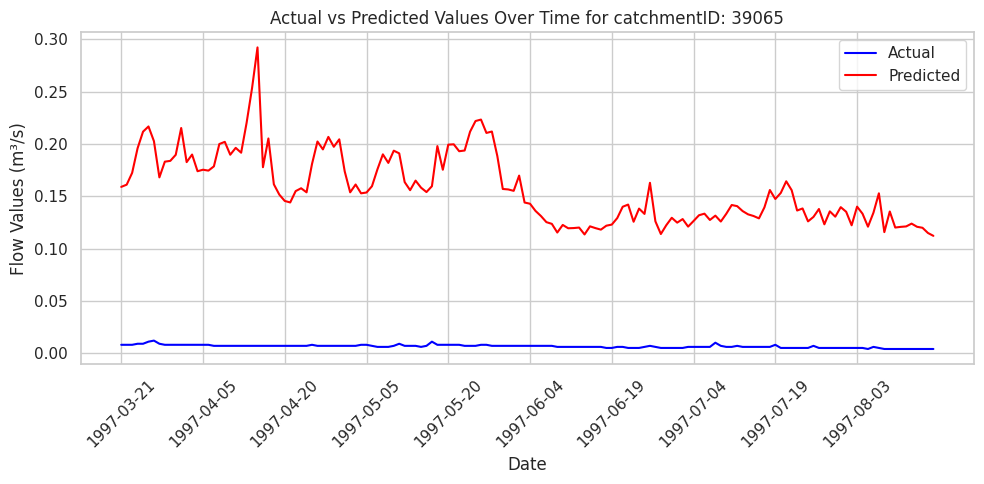

In [115]:
catchment_df = test_results_df[test_results_df["catchmentID"]==low]

n = 5*30

# Prepare data
dates = catchment_df["end_date"].tolist()[:n]
actual = catchment_df["y_test"].tolist()[:n]
predicted = catchment_df["y_test_hat"].tolist()[:n]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, actual, color='blue', label='Actual')
plt.plot(dates, predicted, color='red', label='Predicted')

# Show only 10 evenly spaced ticks on the x-axis
plt.xticks(ticks=pd.Series(dates).iloc[::len(dates)//10], rotation=45)

plt.title(f"Actual vs Predicted Values Over Time for catchmentID: {low}")
plt.xlabel("Date")
plt.ylabel("Flow Values (m³/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# MAE and NSE Scatter plots

/var/tmp/ipykernel_7001/1827188332.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


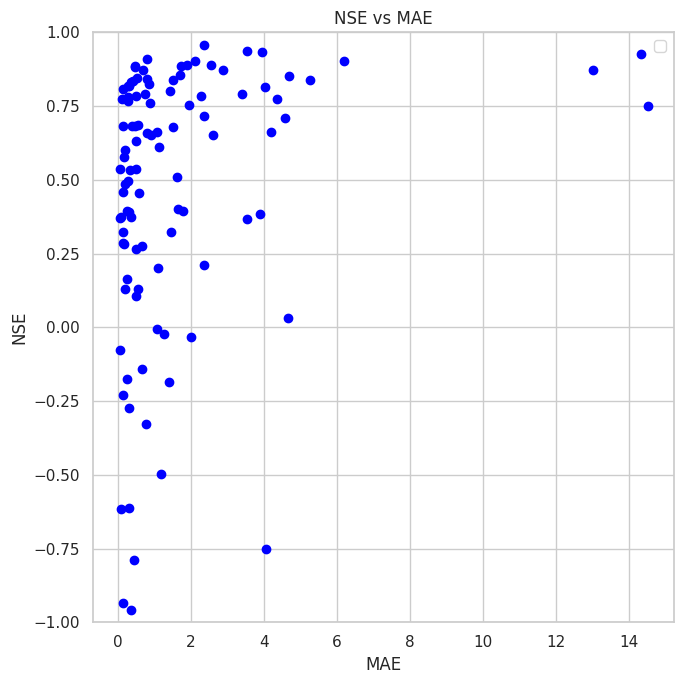

In [116]:
import matplotlib.pyplot as plt

# Example data
x = test_grouped["mae"].tolist()
y = test_grouped["nse"].tolist()

plt.figure(figsize=(7, 7))

# Scatter plots
plt.scatter(x, y, color='blue')

# Labels and title
plt.title("NSE vs MAE")
plt.ylim(-1, 1) 
plt.xlabel("MAE")
plt.ylabel("NSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Cumulative Distribution of NSE Values

In [117]:
# Calculate MAE and NSE per catchmentID
catchment_nse = test_results_df.groupby('catchmentID').apply(
    lambda g: nse(g['y_test'], g['y_test_hat'])
)
print("NSE (by catchment):", round(catchment_nse.mean(), 2))

NSE (by catchment): -0.75


/var/tmp/ipykernel_7001/3724765214.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catchment_nse = test_results_df.groupby('catchmentID').apply(


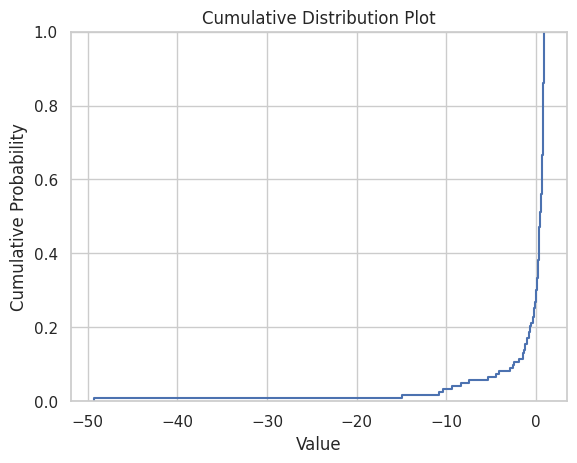

In [118]:
# Example numerical dataset
data = test_grouped["nse"].tolist()

# Set the style for the plot
sns.set(style="whitegrid")

# Create a cumulative distribution plot
sns.ecdfplot(data=data)

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution Plot")

# Show the plot
plt.show()

/var/tmp/ipykernel_7001/2832825788.py:2: RuntimeWarning: invalid value encountered in log1p
  sns.histplot(np.log1p(data), bins=30, kde=True)


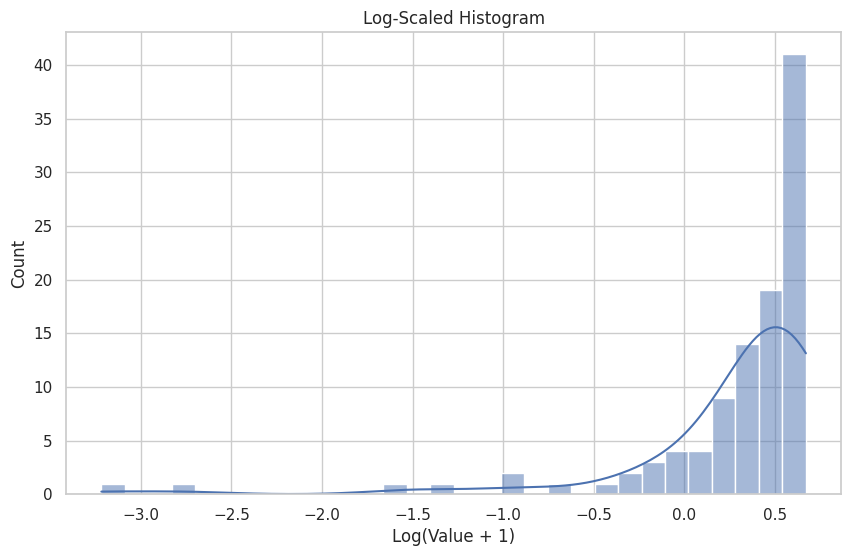

In [119]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(data), bins=30, kde=True)
plt.xlabel("Log(Value + 1)")
plt.title("Log-Scaled Histogram")
plt.show()

In [120]:
print(round(test_grouped["nse"].mean(),2))
print(round(test_grouped["nse"].median(),2))
print(round(test_grouped["nse"].max(),2))
print(round(test_grouped["nse"].min(),2))
# Calculate percentage of values >= 0.5
percentage = (test_grouped["nse"] >= 0.5).mean() * 100

print(f"Percentage of data points >= 0.5: {percentage:.1f}%")

-0.75
0.5
0.96
-49.36
Percentage of data points >= 0.5: 49.6%


# Pearson correlation between NSE/MAE vs. all features

In [46]:
# Group by catchmentID and calculate MAE, count, and NSE
test_grouped = test_results_df.groupby('catchmentID').agg(
    y_test=('y_test', 'mean'),
    y_test_hat=('y_test_hat', 'mean'),
    precipitation=('precipitation', 'mean'),
    area=('area', 'mean'),
    sand_perc=('sand_perc','mean'),
    silt_perc=('silt_perc','mean'),
    clay_perc=('clay_perc','mean'),
    surfacewater_abs=('surfacewater_abs','mean'),
    groundwater_abs=('groundwater_abs','mean'),
    mae=('y_test_abs_diff', 'mean'),
    count=('y_test_abs_diff', 'size'),
    nse=('catchmentID', lambda x: nse(
        test_results_df.loc[x.index, 'y_test'],
        test_results_df.loc[x.index, 'y_test_hat']
    ))
).reset_index()

In [ ]:
features = ["mae", "nse", "y_test", "y_test_hat", "precipitation", "area", "sand_perc", "silt_perc", "clay_perc", "surfacewater_abs", "groundwater_abs"]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_full_health = test_grouped[features].corr()

plt.figure(figsize=(10, 8))
axis_corr = sns.heatmap(
    correlation_full_health,
    vmin=-1, vmax=1, center=0,
    cmap="GnBu",           
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Error Heatmap")
plt.show()

In [ ]:
x = test_grouped["mae"].tolist()
y = test_grouped["y_test"].tolist()

plt.figure(figsize=(7, 7))

# Scatter plots
plt.scatter(x, y, color='blue')

# Labels and title
plt.title("y_test vs MAE")
plt.xlabel("MAE")
plt.ylabel("y_test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()